<div style="text-align: center; padding-top: 12%;">

# Association Rules

## DATA 301 @ WM
    
<figure class="no-fragment">
<center>
<a href="https://github.com/yanhai-xiong/DATA301-AML/blob/main/Module%202%20-%20Reinforcement%20Learning%20and%20Association%20Rules/Section%202.1%20-%20Association%20Rules.ipynb" target="_blank">
    <img class="no-fragment"
         src="https://brand.github.com/_next/static/media/logo-03.cc5e5332.png"
         width="80px"/>
</a>
</center>
</figure>
</div>

> Relative causality and data mining.

# <font color='blue' size=6pt> Motivation </font>
So far, our learning algorithms have been decision-oriented:
- UCB: Which action/arm should I choose next?
- Q-learning: Which action should I choose in each state?

But sometimes there is no action and no reward. Instead, we already have a large collection of observations and want to ask:
> What things tend to occur together?

This leads us to **Association Rule Mining**

# <font color='blue' size=6pt> Introduction </font>

**Example**: Imagine we have a set of sets such as, for example: $\{\{a,b,c\},\{a,b,d,e\},\{a,c,e,f\},\{i,g,k,l\},\{a,b,h,g,n\},\{c,f,i,m\}\}$

The subsets inside the bigger set can be referred as "transactions" if one imagine different purchases at a store.

<font color='red'>Question:</font> in the previous example what were the most frequent items purchased?

<font color='green'>Answer:</font> In that example we had a total of 6 transactions among which 4 transactions had the item "a" purchased and also 3 transactions had both items "a" and "b".


# Association Rule

$X → Y$
1. an antecedent "if" $X$
1. a consequent "then" $Y$
    
<font color='green'>An antecedent is an item found within the data; a consequent is an item likely found **in combination** with the antecedent.</font>

<span style="font-family:Calibri; color:blue; font-size:14pt;">Main Goal:</span> learn efficient machine learning algorithms for analyzing associations or co-occurrences in a database.
- <span style="font-family:Calibri; color:darkred; font-size:12pt;">APRIORI</span>  
- <span style="font-family:Calibri; color:darkgreen; font-size:12pt;">ECLAT</span>

# <font color='blue' size='6pt'> The APRIORI Algorithm </font>


Proposed by R. Agrawal and R. Srikant in 1994 for finding frequent itemsets in a dataset for boolean association rule. Name of the algorithm is Apriori because it uses prior knowledge of frequent itemset properties. We apply an iterative approach or level-wise search where k-frequent itemsets are used to find k+1 itemsets.


- An iterative approach
- Uses prior knowledge of frequent itemset properties: k-frequent itemsets are used to find k+1 itemsets
- Key concepts: **support**, **confidence**, **lift**



The idea is to search for frequent *if-then* patterns; the algorithm uses the concepts of **support** and **confidence** in order to identify the most frequent (and thus relevant) relationships.

<span style="color:blue">Support:</span> is a measure of how frequently the items appear in the dataset of all transactions.

<span style="color:blue">Confidence:</span> represents the number of times the *if-then* statements are found true.

<span style="color:blue">Lift:</span> is metric that can help compare the confidence vs. the *expected* confidence.


## <span style="color:green;font-size:12pt">Examples to Understand Key Concepts</span>
For the association rule **DATA 201 → DATA 301**:

**Support:** How frequently **DATA 201 and DATA 301 occur together** among all students:
$
\text{Support}
= P(\text{DATA201} \cap \text{DATA301})
= \frac{\text{# students who took both DATA 201 and DATA 301}}
{\text{Total # students}}
$

**Confidence:** Among students who took **DATA 201**, the probability that they also took **DATA 301**:
$
\text{Confidence}
= P(\text{DATA301}\mid\text{DATA201})
= \frac{P(\text{DATA201} \cap \text{DATA301})}
{P(\text{DATA201})}
$

**Lift:** How much more likely a student who took **DATA 201** is to take
**DATA 301**, compared with a randomly selected student:
$
\text{Lift}
= \frac{P(\text{DATA301}\mid\text{DATA201})}
{P(\text{DATA301})}
= \frac{\text{Confidence}}
{P(\text{DATA301})}
$


## Interpretation
For a given association rule
- $\text{Lift} > 1$: positive association
- $\text{Lift} = 1$: no association
- $\text{Lift} < 1$: negative association
Association-rule mining searches for interesting rules among many possible rules, rather than manually testing every possible association.



## Example: Apriori Algorithm
<span style="color:red;font-size:14pt">

**APRIORI Property:**
- **All subsets of a frequent itemset must also be frequent.**
- If an **itemset is infrequent**, all of its supersets must also be infrequent.
</span>

Consider the following transaction dataset:
<span style="color:green;font-size:14pt">

| TID | Items          |
| --- | -------------- |
| T1  | i1, i2, i5     |
| T2  | i2, i4         |
| T3  | i2, i3         |
| T4  | i1, i2, i4     |
| T5  | i1, i3         |
| T6  | i2, i3         |
| T7  | i1, i3         |
| T8  | i1, i2, i3, i5 |
| T9  | i1, i2, i3     |

</span>

Suppose we use **Minimum support count = 2** and **Minimum confidence = 60%**


### **Step 1: Find Frequent 1-Itemsets**

Count how many transactions contain each item:

| Itemset | Support Count |
| ------: | ------------: |
|      i1 |             6 |
|      i2 |             7 |
|      i3 |             6 |
|      i4 |             2 |
|      i5 |             2 |

All five items have support count $\geq 2$, so all are **frequent 1-itemsets**.


### **Step 2: Find Frequent 2-Itemsets**

Generate candidate pairs and count their occurrences:

| Itemset | Support Count | Frequent? |
| ------: | ------------: | :-------: |
|  i1, i2 |             4 |     ✓     |
|  i1, i3 |             4 |     ✓     |
|  i1, i4 |             1 |     ✗     |
|  i1, i5 |             2 |     ✓     |
|  i2, i3 |             4 |     ✓     |
|  i2, i4 |             2 |     ✓     |
|  i2, i5 |             2 |     ✓     |
|  i3, i4 |             0 |     ✗     |
|  i3, i5 |             1 |     ✗     |
|  i4, i5 |             0 |     ✗     |

Therefore, the frequent 2-itemsets are
$
\{i1,i2\},\{i1,i3\},\{i1,i5\},
\{i2,i3\},\{i2,i4\},\{i2,i5\}.
$

According to the **Apriori property**, an infrequent itemset cannot be a subset of a frequent larger itemset. Therefore, pairs such as $\{i1,i4\}$ can be used to prune candidate 3-itemsets.


### **Step 3: Find Frequent 3-Itemsets**

After applying Apriori pruning, the relevant candidate 3-itemsets are:

|    Itemset | Support Count | Frequent? |
| ---------: | ------------: | :-------: |
| i1, i2, i3 |             2 |     ✓     |
| i1, i2, i5 |             2 |     ✓     |

Thus,
$
L_3 =
\{\{i1,i2,i3\},\{i1,i2,i5\}\}.
$

Can we generate a frequent 4-itemset?

**No candidate 4-itemset needs to be evaluated, and Apriori stops.**


### Generate Association Rules

Once the frequent itemsets have been identified, we can generate association rules.

For a rule
$
A\rightarrow B,
$
where $A\cap B=\emptyset$,

$$
\text{Confidence}(A\rightarrow B)
=
\frac{\text{Support Count}(A\cup B)}
{\text{Support Count}(A)}.
$$

We retain only rules having
$
\text{Confidence}\geq60\%.
$


For example, consider the frequent itemset $\{i1,i5\}$.

> Rule: $ i5 \rightarrow i1 $
$
\text{Confidence}(i5\rightarrow i1)
=
\frac{\text{Support Count}(i1,i5)}
{\text{Support Count}(i5)}
=
\frac{2}{2}
=
100\%.
$

Therefore, this rule passes the minimum-confidence threshold.

Its lift is
$
\text{Lift}(i5\rightarrow i1)
=
\frac{P(i1\mid i5)}{P(i1)}
=
\frac{1}{6/9}
=
1.50.
$

> So transactions containing \(i5\) are **1.5 times as likely** to contain \(i1\) compared with a randomly selected transaction.



Another example is

$$
i4\rightarrow i2.
$$

Since every transaction containing \(i4\) also contains \(i2\),

$$
\text{Confidence}(i4\rightarrow i2)
=
\frac{2}{2}
=
100\%.
$$

Its lift is

$$
\text{Lift}(i4\rightarrow i2)
=
\frac{1}{7/9}
=
1.286.
$$





What About $\{i1,i2,i3\}$?

The frequent itemset $\{i1,i2,i3\}$ generates rules such as

$$
(i1,i2)\rightarrow i3,
$$

with

$$
\text{Confidence}
=
\frac{2}{4}
=
50\%.
$$

Similarly,

$$
(i1,i3)\rightarrow i2=\frac24=50\%,
$$

and

$$
(i2,i3)\rightarrow i1=\frac24=50\%.
$$

Since all of these are below the **60% minimum confidence**, they are discarded.

This illustrates an important distinction:

> **A frequent itemset does not necessarily produce a strong association rule.**



## Practical Apriori Workflow

1. **Choose minimum support and minimum confidence.**
2. **Find frequent 1-itemsets.**
3. **Generate larger candidate itemsets and use the Apriori property to prune candidates:**
$\text{infrequent itemset}
   \Rightarrow
   \text{all of its supersets are infrequent}.$
4. **Repeat until no larger frequent itemsets can be generated.**
5. **Generate association rules from the frequent itemsets.**
6. **Calculate confidence and discard rules below the minimum confidence.**
7. **Calculate lift (and possibly other metrics) for the remaining rules to evaluate the strength of the associations.**

# <font color='blue' size=6pt>The ECLAT Algorithm</font>

**ECLAT** stands for **Equivalence class Clustering and bottom-up LAttice Traversal**.

<span style="font-family:Calibri; color:blue; font-size:13pt">

**Main Idea:** ECLAT represents each item using its **Transaction ID Set (TID-set)** and finds frequent itemsets by **intersecting TID-sets**.

</span>

Instead of repeatedly scanning the transaction database, ECLAT converts the data from a **horizontal representation**
$
TID \rightarrow \text{Items}
$
to a **vertical representation**
$
\text{Item} \rightarrow \{TIDs\}.
$
- For two items $A$ and $B$,
$
T(A,B)=T(A)\cap T(B),
$
- and therefore
$
\text{Support Count}(A,B)
=
|T(A)\cap T(B)|.
$


## <span style="color:green;font-size:12pt">Simple Example: Movie Preferences</span>

Suppose 1,000 users rate movies.

If
$
T(\text{Star Wars IV})\cap T(\text{Star Wars V})
$
contains 900 users, then

$$
\text{Support}(\text{Star Wars IV, Star Wars V})
=
\frac{900}{1000}
=
0.9.
$$

If
$
T(\text{Star Wars IV})\cap T(\text{Star Wars I})
$
contains only 100 users, then

$$
\text{Support}(\text{Star Wars IV, Star Wars I})
=
\frac{100}{1000}
=
0.1.
$$

Thus, the size of the **TID-set intersection** directly gives us the support count.


## **ECLAT Steps**

1. Convert the transaction database into the **vertical TID-set representation**.
2. Choose a **minimum support**.
3. Intersect TID-sets to generate larger candidate itemsets.
4. Keep itemsets whose TID-set size satisfies the minimum support:
$
|T(X)|\geq \text{minimum support count}.
$
5. Recursively extend frequent itemsets until no larger frequent itemsets can be generated.


## <span style="color:green;font-size:12pt">Example: Frequently Bought Items in a Grocery Store</span>

Consider the following transactions:

| TID | Bread | Butter | Milk | Juice | Jam |
| --: | ----: | -----: | ---: | ----: | --: |
|  T1 |     1 |      1 |    0 |     0 |   1 |
|  T2 |     0 |      1 |    0 |     1 |   0 |
|  T3 |     0 |      1 |    1 |     0 |   0 |
|  T4 |     1 |      1 |    0 |     1 |   0 |
|  T5 |     1 |      0 |    1 |     0 |   0 |
|  T6 |     0 |      1 |    1 |     0 |   0 |
|  T7 |     1 |      0 |    1 |     0 |   0 |
|  T8 |     1 |      1 |    1 |     0 |   1 |
|  T9 |     1 |      1 |    1 |     0 |   0 |

Suppose
$
\text{minimum support count}=2.
$


### **Step 1: $k=1$ — Construct TID-sets**

Convert the horizontal transaction table into a vertical representation:

| Item   | TID-set                      | Support Count |
| ------ | ---------------------------- | ------------: |
| Bread  | {T1, T4, T5, T7, T8, T9}     |             6 |
| Butter | {T1, T2, T3, T4, T6, T8, T9} |             7 |
| Milk   | {T3, T5, T6, T7, T8, T9}     |             6 |
| Juice  | {T2, T4}                     |             2 |
| Jam    | {T1, T8}                     |             2 |

All items have support count $\geq2$, so all are frequent.


### **Step 2: $k=2$ — Intersect TID-sets**

For example,
$
T(\text{Bread, Butter})
=
T(\text{Bread})\cap T(\text{Butter})
=
\{T1,T4,T5,T7,T8,T9\}
\cap
\{T1,T2,T3,T4,T6,T8,T9\}
=
\{T1,T4,T8,T9\}.
$

Therefore,
$
\text{Support Count}(\text{Bread, Butter})=4.
$


Doing this for all pairs:

| Itemset         | TID-set          | Support Count | Frequent? |
| --------------- | ---------------- | ------------: | :-------: |
| {Bread, Butter} | {T1, T4, T8, T9} |             4 |     ✓     |
| {Bread, Milk}   | {T5, T7, T8, T9} |             4 |     ✓     |
| {Bread, Juice}  | {T4}             |             1 |     ✗     |
| {Bread, Jam}    | {T1, T8}         |             2 |     ✓     |
| {Butter, Milk}  | {T3, T6, T8, T9} |             4 |     ✓     |
| {Butter, Juice} | {T2, T4}         |             2 |     ✓     |
| {Butter, Jam}   | {T1, T8}         |             2 |     ✓     |
| {Milk, Juice}   | $\emptyset$      |             0 |     ✗     |
| {Milk, Jam}     | {T8}             |             1 |     ✗     |
| {Juice, Jam}    | $\emptyset$      |             0 |     ✗     |

Only itemsets with support count $\geq2$ are retained.


### **Step 3: $k=3$ — Continue Intersections**

We can continue extending the frequent itemsets.

For example,
$
T(\text{Bread, Butter, Milk})
=
T(\text{Bread, Butter})\cap T(\text{Milk})
=
\{T1,T4,T8,T9\}
\cap
\{T3,T5,T6,T7,T8,T9\}
=
\{T8,T9\}.
$

Similarly,

| Itemset               | TID-set  | Support Count |
| --------------------- | -------- | ------------: |
| {Bread, Butter, Milk} | {T8, T9} |             2 |
| {Bread, Butter, Jam}  | {T1, T8} |             2 |

Both satisfy the minimum support.


### **Step 4: $k=4$**

The possible extension
$
\{\text{Bread, Butter, Milk, Jam}\}
$
has
$
T(\text{Bread, Butter, Milk, Jam})=\{T8\}.
$

Thus,
$
\text{Support Count}=1<2.
$

It is **not frequent**, so the search terminates.


## **Frequent Itemsets vs. Association Rules**

ECLAT itself finds **frequent itemsets**. It does **not automatically imply a recommendation** such as
$
\text{Bread}\rightarrow\text{Butter}.
$

After finding frequent itemsets, we generate association rules and evaluate their **confidence** and **lift**.

For example,
$
\text{Confidence}(\text{Bread}\rightarrow\text{Butter})
=
\frac{\text{Support Count}(\text{Bread, Butter})}
{\text{Support Count}(\text{Bread})}
=
\frac46
=
66.7\%.
$

Its lift is
$
\text{Lift}(\text{Bread}\rightarrow\text{Butter})
=
\frac{4/6}{7/9}
\approx0.857.
$

Interestingly, although Bread and Butter occur together frequently, their lift is less than 1. Thus, the frequent itemset alone does **not** necessarily indicate a strong positive association.



For another example,

$$
\text{Confidence}(\text{Jam}\rightarrow\text{Bread})
=
\frac22
=
100\%,
$$

and

$$
\text{Lift}(\text{Jam}\rightarrow\text{Bread})
=
\frac{1}{6/9}
=
1.5.
$$

This rule shows a stronger positive association.


# **ECLAT vs. Apriori**

Both algorithms find **frequent itemsets**, but they search differently:

| Apriori                                                   | ECLAT                                                          |
| --------------------------------------------------------- | -------------------------------------------------------------- |
| Primarily uses transaction scans and candidate generation | Uses vertical TID-sets                                         |
| Counts support by checking transactions                   | Counts support through TID-set intersections                   |
| Breadth-first search is common                            | Depth-first search is common                                   |
| Can require repeated database scans                       | After vertical conversion, relies heavily on set intersections |

The central idea of ECLAT can therefore be summarized as:

$$
\boxed{
\text{Itemset Extension}
\rightarrow
\text{TID-set Intersection}
\rightarrow
\text{Support Count}
\rightarrow
\text{Prune if Infrequent}
}
$$


# <font color='blue'> Code Applications </font>
---

### Example for the APRIORI algorithm in Python with real data

In [2]:
!pip install -q apyori
!pip install -q pandas pyfim

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.3/357.3 kB 575.4 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
# this script is assuming that the apyori.py and pyfim.py scripts (along with the data) are uploaded
import pandas as pd
import numpy as np
from apyori import apriori
from fim import eclat
import matplotlib.pyplot as plt

In [4]:
order_data = pd.read_csv('https://raw.githubusercontent.com/yanhai-xiong/DATA301-AML/main/Data%20Sets/order_products_train.csv?raw=true')
product_data = pd.read_csv('https://raw.githubusercontent.com/yanhai-xiong/DATA301-AML/main/Data%20Sets/products.csv')

In [5]:
# inspect the content of order_data
order_data.head(20)

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1
5,1,13176,6,0
6,1,47209,7,0
7,1,22035,8,1
8,36,39612,1,0
9,36,19660,2,1


In [6]:
product_data.head(100)

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
...,...,...,...,...
95,96,Sprinklez Confetti Fun Organic Toppings,97,13
96,97,Organic Chamomile Lemon Tea,94,7
97,98,2% Yellow American Cheese,2,16
98,99,Local Living Butter Lettuce,83,4


In [7]:
# how many different products are recorded?
len(product_data)

49688

In [8]:
# here we merged the two data sets for connecting the barcode with the name of the actual product
# we save the result into a new data frame called named_orders
named_orders = pd.merge(order_data,product_data,on='product_id')
named_orders.sort_values('product_id')

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
831805,2050666,1,6,0,Chocolate Sandwich Cookies,61,19
667706,1641609,1,1,1,Chocolate Sandwich Cookies,61,19
1298643,3207223,1,28,0,Chocolate Sandwich Cookies,61,19
749575,1845054,1,11,0,Chocolate Sandwich Cookies,61,19
1091916,2698866,1,1,0,Chocolate Sandwich Cookies,61,19
...,...,...,...,...,...,...,...
446055,1092104,49687,1,0,Smartblend Healthy Metabolism Dry Cat Food,41,8
1014644,2508423,49688,3,0,Fresh Foaming Cleanser,73,11
891142,2198380,49688,10,0,Fresh Foaming Cleanser,73,11
1209047,2986153,49688,16,0,Fresh Foaming Cleanser,73,11


In [9]:
named_orders

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
0,1,49302,1,1,Bulgarian Yogurt,120,16
1,1,11109,2,1,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16
2,1,10246,3,0,Organic Celery Hearts,83,4
3,1,49683,4,0,Cucumber Kirby,83,4
4,1,43633,5,1,Lightly Smoked Sardines in Olive Oil,95,15
...,...,...,...,...,...,...,...
1384612,3421063,14233,3,1,Natural Artesian Water,115,7
1384613,3421063,35548,4,1,Twice Baked Potatoes,13,20
1384614,3421070,35951,1,1,Organic Unsweetened Almond Milk,91,16
1384615,3421070,16953,2,1,Creamy Peanut Butter,88,13


## Count Analysis

In [10]:
# get the count for the different products purchased
counts = named_orders['product_name'].value_counts()
# the top 200 most purchased products
counts.head(30)

,count
product_name,
Banana,18726
Bag of Organic Bananas,15480
Organic Strawberries,10894
Organic Baby Spinach,9784
Large Lemon,8135
Organic Avocado,7409
Organic Hass Avocado,7293
Strawberries,6494
Limes,6033


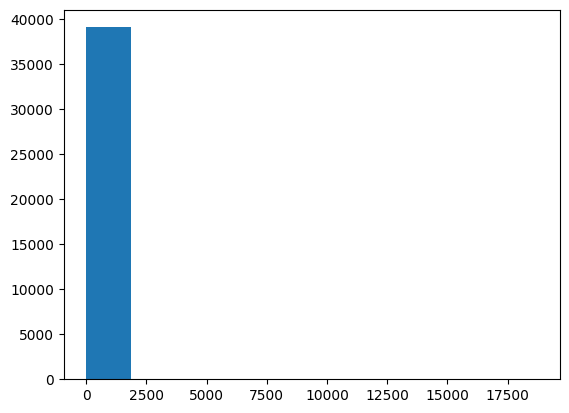

In [11]:
plt.hist(counts)
plt.show()

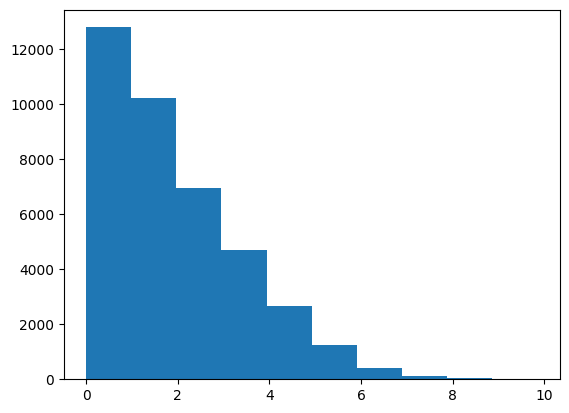

In [12]:
# we need a log transform because of the differences in the order of magnitudes between different counts
plt.hist(np.log(counts))
plt.show()

In [13]:
# how many transactions do we have?
len(named_orders['order_id'].unique())

131209

In [14]:
# we can apply Otsu's method to threshold the count values
# we need candidate percentiles
t = np.linspace(25,90,num=200)
cost = [] # this is not dollars
data = np.log(counts)

In [15]:
# now we generate all "cost" values
for i in t:
  data1 = data[data<np.percentile(data,i)]
  data2 = data[data>=np.percentile(data,i)]
  cost.append(i*np.var(data1)+(100-i)*np.var(data2))

In [16]:
v = counts[np.argmin(cost)]

/tmp/ipykernel_2681/3872638547.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  v = counts[np.argmin(cost)]


In [17]:
t[np.argmin(cost)]

np.float64(63.869346733668344)

In [18]:
v

np.int64(1183)

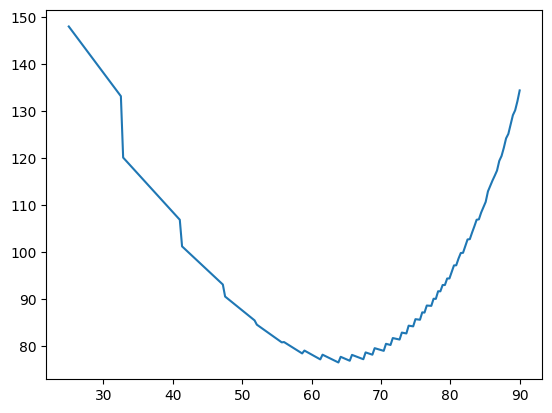

In [19]:
# plot the cost vs percentage
plt.plot(t,cost)
plt.show()

In [20]:
cost

[np.float64(147.93370862526592),
 np.float64(147.2894412175177),
 np.float64(146.6451738097695),
 np.float64(146.00090640202126),
 np.float64(145.35663899427303),
 np.float64(144.7123715865248),
 np.float64(144.06810417877657),
 np.float64(143.42383677102833),
 np.float64(142.77956936328013),
 np.float64(142.1353019555319),
 np.float64(141.49103454778367),
 np.float64(140.84676714003544),
 np.float64(140.2024997322872),
 np.float64(139.55823232453898),
 np.float64(138.91396491679077),
 np.float64(138.26969750904252),
 np.float64(137.6254301012943),
 np.float64(136.98116269354608),
 np.float64(136.33689528579785),
 np.float64(135.69262787804962),
 np.float64(135.0483604703014),
 np.float64(134.40409306255316),
 np.float64(133.75982565480496),
 np.float64(133.11555824705673),
 np.float64(120.07591067361669),
 np.float64(119.54718754987374),
 np.float64(119.0184644261308),
 np.float64(118.48974130238786),
 np.float64(117.96101817864493),
 np.float64(117.43229505490199),
 np.float64(116.90

In [ ]:
p = t[np.argmin(cost)]
print('the percentage value for the chosen percentile  is : '+str(p))

the percentage value for the chosen percentile  is : 63.88888888888889


## Hardthresholding the most frequently transacted items

In [21]:
# here we create a hard threshold for the frequency of products being transacted
v = 500

In [22]:
counts

,count
product_name,
Banana,18726
Bag of Organic Bananas,15480
Organic Strawberries,10894
Organic Baby Spinach,9784
Large Lemon,8135
...,...
Clear Complexion Daily Moisturizer,1
Classic Original Lip Balm SPF 12,1
Sprinkles Decors,1


## Subsetting

We subset the dataframe based on the value of the hard threshold.

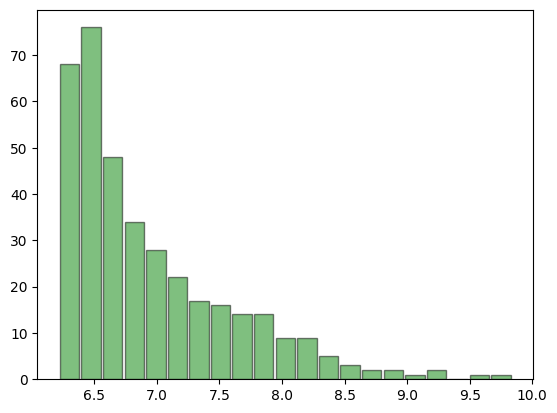

In [ ]:
# we can visualize this the frequency distribution as a histogram and retain a list with the most frequently purchased
counts = counts[counts > v] # this is the thresholding part
plt.hist(np.log(counts.values), bins=21,color='green',edgecolor='k',rwidth=0.9,alpha=0.5)
plt.show()

In [ ]:
counts

product_name
Banana                            18726
Bag of Organic Bananas            15480
Organic Strawberries              10894
Organic Baby Spinach               9784
Large Lemon                        8135
                                  ...  
Strawberry Rhubarb Yoghurt          507
Blueberry Yoghurt                   506
Cran Raspberry Sparkling Water      503
Tomato Paste                        503
Organic Red Delicious Apple         501
Name: count, Length: 372, dtype: int64

In [ ]:
# IMPORTANT
# here we subset the "selected" orders
selected_orders = named_orders[named_orders['product_name'].isin(counts.index.values.tolist())]
selected_orders

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
2,1,10246,3,0,Organic Celery Hearts,83,4
3,1,49683,4,0,Cucumber Kirby,83,4
5,1,13176,6,0,Bag of Organic Bananas,24,4
6,1,47209,7,0,Organic Hass Avocado,24,4
7,1,22035,8,1,Organic Whole String Cheese,21,16
...,...,...,...,...,...,...,...
1384599,3421056,21709,3,1,Sparkling Lemon Water,115,7
1384610,3421063,49235,1,1,Organic Half & Half,53,16
1384612,3421063,14233,3,1,Natural Artesian Water,115,7
1384614,3421070,35951,1,1,Organic Unsweetened Almond Milk,91,16


## We need to extract the different transactions

We apply a pivotting of the data frame.

In [ ]:
# here we pivot the data frame to see the products transacted in each purchase order
pd.options.mode.chained_assignment = None
selected_orders['cols'] = selected_orders.groupby('order_id').cumcount()
selected_pivot = selected_orders.pivot(index = 'order_id',columns = 'cols')[['product_name']]

In [ ]:
selected_pivot

product_name  \
cols                                                     0    
order_id                                                      
1                                     Organic Celery Hearts   
36                                             Spring Water   
38                                     Organic Baby Arugula   
96                                         Organic Cucumber   
98                                     Natural Spring Water   
...                                                     ...   
3421026   Organic Sticks Low Moisture Part Skim Mozzarel...   
3421049                               Organic Baby Broccoli   
3421056                               Sparkling Lemon Water   
3421063                                 Organic Half & Half   
3421070                     Organic Unsweetened Almond Milk   

                                                                   \
cols                          1                                2    
order_id                                                            
1                 Cucumber Kirby           Bag of Organic Bananas   
36           Organic Half & Half               Super Greens Salad   
38              Bunched Cilantro              Flat Parsley, Bunch   
96        Organic Grape Tomatoes              Organic Raspberries   
98        Bag of Organic Bananas  Organic Unsweetened Almond Milk   
...                          ...                              ...   
3421026                      NaN                              NaN   
3421049                      NaN                              NaN   
3421056                      NaN                              NaN   
3421063   Natural Artesian Water                              NaN   
3421070     Creamy Peanut Butter                              NaN   

                                                                          \
cols                                     3                            4    
order_id                                                                   
1                      Organic Hass Avocado  Organic Whole String Cheese   
36        Organic Garnet Sweet Potato (Yam)                    Asparagus   
38                                      NaN                          NaN   
96               Organic Whole Strawberries          Organic Blueberries   
98                      Organic Raspberries                    Guacamole   
...                                     ...                          ...   
3421026                                 NaN                          NaN   
3421049                                 NaN                          NaN   
3421056                                 NaN                          NaN   
3421063                                 NaN                          NaN   
3421070                                 NaN                          NaN   

                                                       \
cols               5                               6    
order_id                                                
1                 NaN                             NaN   
36                NaN                             NaN   
38                NaN                             NaN   
96                NaN                             NaN   
98        Black Beans  Organic Raw Kombucha Gingerade   
...               ...                             ...   
3421026           NaN                             NaN   
3421049           NaN                             NaN   
3421056           NaN                             NaN   
3421063           NaN                             NaN   
3421070           NaN                             NaN   

                                                                            \
cols                              7                     8               9    
order_id                                                                     
1                                NaN                   NaN             NaN   
36                   

In [ ]:
# the total number of different products if we threshold at v
len(selected_pivot.columns)

34

## Preparing the list of purchases

In [ ]:
# now we can get the list of the purchased items for each transaction
purchases = []
for i in range(0,len(selected_pivot)):
    purchases.append([str(selected_pivot.values[i,j]) for j in range(0,len(selected_pivot.columns))])

## Check your understanding

What is the variable 'purchases?'

ANSWER: it represents a list of lists.

In [ ]:
# we got the list of all transactions called "purchases"
purchases[0]

['Organic Celery Hearts',
 'Cucumber Kirby',
 'Bag of Organic Bananas',
 'Organic Hass Avocado',
 'Organic Whole String Cheese',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan',
 'nan']

In [ ]:
# ex. purchased items in the ith transaction - only three items: Bananas, Pure Irish Butter and Michigan organic Kale
len(purchases[1])

34

## We need to clean the 'purchases' from the 'nans.'

In [ ]:
# we want a clean list of transactions that is without any "nan" items
cleanList = []
for i in range(len(purchases)):
  cleanList.append([x for x in purchases[i] if str(x) != 'nan'])

In [ ]:
cleanList[0]

['Organic Celery Hearts',
 'Cucumber Kirby',
 'Bag of Organic Bananas',
 'Organic Hass Avocado',
 'Organic Whole String Cheese']

## Application of the APRIORI Algorithm

In [ ]:
# we are providing the clean list to the "apriori" algorithm
rules = apriori(cleanList, min_support = 0.02, min_confidence = 0.02, min_lift=2,max_length=2)

We are now ready for getting the association rules

In [ ]:
rules

<generator object apriori at 0x7f7673bf4a50>

In [ ]:
# we need to unpack or 'list' the rules created.
results = list(rules)

## We got a structure with many nested lists

In [ ]:
len(results)

2

In [ ]:
results[0][2][0][2]

0.08191214470284237

The support of two items is

$$\text{P}(\text{both }A\text{ and } B):=\text{P}(A\cap B)=\text{P}(B\cap A)$$

The lift can be computed as:

$$\text{Lift}:=\frac{\text{P}(A\cap B)}{\text{P}(A)\cdot \text{P}(B)}$$

To establish a sense of the empirical causality we need the confidence, and we say that

$$A \implies B$$

if

$$\text{P}(B|A) > \text{P}(A|B)$$

In [ ]:
results

In [ ]:
# Bag of Org Bananas -> Org Haas Avocado and also we can explore Org Haas Avocado -> Bag Org. Bananas

In [ ]:
list(results[0].ordered_statistics[0].items_add)

['Organic Hass Avocado']

In [ ]:
items = [x for x in results[0]]

In [ ]:
items

['Organic Strawberries', 'Organic Raspberries']

In [ ]:
#results[0].ordered_statistics[0].confidence

In [ ]:
results[0].ordered_statistics[1].confidence

0.2748753522653371

In [ ]:
rules = 0
for result in results:
  supp   = int(result.support*10000)/100
  if result.ordered_statistics[0].confidence > result.ordered_statistics[1].confidence:
    i = 0
  else:
    i = 1
  conf   = int(result.ordered_statistics[i].confidence*100)
  hypo   = ''.join([x+' ' for x in result.ordered_statistics[i].items_base])
  conc   = ''.join([x+' ' for x in result.ordered_statistics[i].items_add])
  rules = rules + 1
  print("If "+str(hypo)+" is purchased, " +str(conf)+" % of the time " + str(conc)+" is purchased [support - " +
        str(supp)+"%]"+'  Lift: '+str(round(result.ordered_statistics[i].lift,2)))
print("Total rules built : " +str(rules))

If Organic Hass Avocado  is purchased, 33 % of the time Bag of Organic Bananas  is purchased [support - 2.18%]  Lift: 2.37
If Organic Strawberries  is purchased, 28 % of the time Bag of Organic Bananas  is purchased [support - 2.78%]  Lift: 2.01
Total rules built : 2


## How to present the rules

In [ ]:
nr = 0
confidence = []
lift = []
for item in results:
    pair = item[0]
    # We cannot seem to tell apriori to ignore NaN items, so we will refrain from printing results containing them
    # they will be returned as lower-case text "nan".
    if "nan" not in pair:
        if item[2][0][2] > item[2][1][2]:
          items = [x for x in pair]
          print("Rule: " + items[0] + " => " + items[1])

          #second index of the inner list
          print("Support: " + str(round(item[1]*100,2)) + "%")

          #third index of the list located at 0th
          #of the third index of the inner list
          confidence.append(round( item[2][0][2]*100,2))
          print("Confidence: " + str(round( item[2][0][2]*100,2)) + "%")
          lift.append(round( item[2][0][2]*100,2))
          print("Lift: " + str( round(item[2][0][3],2) ))
          nr += 1
        else:
          items = [x for x in pair]
          print("Rule: " + items[1] + " => " + items[0])

          #second index of the inner list
          print("Support: " + str(round(item[1]*100,2)) + "%")

          #third index of the list located at 0th
          #of the third index of the inner list
          confidence.append(round( item[2][1][2]*100,2))
          print("Confidence: " + str(round( item[2][1][2]*100,2)) + "%")
          lift.append(round( item[2][1][2]*100,2))
          print("Lift: " + str( round(item[2][1][3],2) ))
          nr += 1

Rule: Bag of Organic Bananas => Organic Cucumber
Support: 1.08%
Confidence: 27.49%
Lift: 2.09
Rule: Organic Hass Avocado => Bag of Organic Bananas
Support: 2.06%
Confidence: 33.18%
Lift: 2.52
Rule: Organic Raspberries => Bag of Organic Bananas
Support: 1.51%
Confidence: 32.1%
Lift: 2.44
Rule: Organic Strawberries => Bag of Organic Bananas
Support: 2.62%
Confidence: 28.22%
Lift: 2.14
Rule: Banana => Honeycrisp Apple
Support: 1.05%
Confidence: 34.67%
Lift: 2.18
Rule: Banana => Organic Fuji Apple
Support: 1.03%
Confidence: 37.15%
Lift: 2.33
Rule: Limes => Large Lemon
Support: 1.36%
Confidence: 26.44%
Lift: 3.82
Rule: Organic Avocado => Large Lemon
Support: 1.15%
Confidence: 18.21%
Lift: 2.63
Rule: Organic Avocado => Organic Baby Spinach
Support: 1.19%
Confidence: 18.92%
Lift: 2.27
Rule: Organic Baby Spinach => Organic Hass Avocado
Support: 1.07%
Confidence: 17.17%
Lift: 2.06
Rule: Organic Strawberries => Organic Blueberries
Support: 1.08%
Confidence: 25.55%
Lift: 2.76
Rule: Organic Hass A

In [ ]:
np.max(confidence)

37.15

## Example for the ECLAT algorithm in Python with real data

In [ ]:
rule_count = 0
rules = eclat(cleanList, supp=1, zmin=2)
for i in range(0,len(rules)):
    supp = round(int(rules[i][1])/len(purchases)*100,3)
    items = rules[i][0]
    if "nan" not in items:
        rule_count = rule_count +1
        item_1 = rules[i][0][0]
        item_2 = rules[i][0][1]
        print("If "+str(item_1)+" is purchased, "+str(supp)+"% of the time " + str(item_2)+" is purchased [absolute support=" +str(rules[i][1])+"]")
print("Total rules built : " +str(rule_count))

If Organic Strawberries is purchased, 1.85% of the time Banana is purchased [absolute support=2174]
If Organic Strawberries is purchased, 2.615% of the time Bag of Organic Bananas is purchased [absolute support=3074]
If Organic Baby Spinach is purchased, 1.702% of the time Banana is purchased [absolute support=2000]
If Organic Baby Spinach is purchased, 1.902% of the time Bag of Organic Bananas is purchased [absolute support=2236]
If Organic Baby Spinach is purchased, 1.394% of the time Organic Strawberries is purchased [absolute support=1639]
If Large Lemon is purchased, 1.836% of the time Banana is purchased [absolute support=2158]
If Large Lemon is purchased, 1.053% of the time Organic Baby Spinach is purchased [absolute support=1238]
If Organic Avocado is purchased, 1.885% of the time Banana is purchased [absolute support=2216]
If Organic Avocado is purchased, 1.193% of the time Organic Baby Spinach is purchased [absolute support=1402]
If Organic Avocado is purchased, 1.148% of the

In [ ]:
rules_e = eclat(purchases, supp=1, zmin=2)
eclat_final = [];
for item in rules_e:
    pair = item[0]
    if "nan" not in pair:
        #print(pair)
        eclat_final.append([item[0][0], item[0][1], item[1]])
eclat_final = pd.DataFrame(eclat_final, columns = ['Item1', 'Item2', 'Support'])
eclat_final.sort_values(by=['Support'],ascending=False)

,Item1,Item2,Support
1,Organic Strawberries,Bag of Organic Bananas,3074
10,Organic Hass Avocado,Bag of Organic Bananas,2420
3,Organic Baby Spinach,Bag of Organic Bananas,2236
7,Organic Avocado,Banana,2216
0,Organic Strawberries,Banana,2174
5,Large Lemon,Banana,2158
2,Organic Baby Spinach,Banana,2000
13,Strawberries,Banana,1948
16,Organic Raspberries,Bag of Organic Bananas,1780
17,Organic Raspberries,Organic Strawberries,1670
